# Random Forest w/Expanded Features & Weighting Comparison

Note: Values in this notebook might slightly differ from what was reported in the final model comparison notebook due to additional runs post-reporting.

In [1]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
#Citations to investigate
#Anisha, S. S., Nargunam, A. S., & Shameem, M. (2024). Machine Learning Methods to Predict and Classify Poverty. In Smart Technologies for Sustainable Development Goals (pp. 159-177). CRC Press.
#Hindman, M. (2015). Building better models: Prediction, replication, and machine learning in the social sciences. The Annals of the American Academy of Political and Social Science, 659(1), 48-62.
#Venkatramolla, S. K. (2019). Machine learning and data science for a household-specific poverty level prediction task.

---
## 1) Random Forest on Engineered Feature Set — 4-Class 

Using the same engineered CSVs and optimal feature list from *3c_Preprocessing_XGBoost.ipynb*,
but targeting the full 4-class *poverty_risk_score* (0 = Stable, 1 = Near Poverty, 2 = Poverty, 3 = Deep Poverty).

In [3]:
import json
import pandas as pd
from pathlib import Path

data_dir = Path("../3_Data_Preprocessing/preprocessing_data")

# Load engineered train/test sets
df_train_eng = pd.read_csv(data_dir / "train_engineered.csv")
df_test_eng  = pd.read_csv(data_dir / "test_engineered.csv")

# Load feature metadata produced by the XGBoost preprocessing notebook
with open(data_dir / "feature_engineering_metadata.json") as f:
    metadata = json.load(f)

optimal_features = metadata["optimal_features"]

# 4-class target
X_train_4c = df_train_eng[optimal_features]
y_train_4c = df_train_eng["poverty_risk_score"]

X_test_4c = df_test_eng[optimal_features]
y_test_4c = df_test_eng["poverty_risk_score"]

print(f"Optimal features ({len(optimal_features)}): {optimal_features}")
print(f"X_train_4c: {X_train_4c.shape}, y_train_4c: {y_train_4c.shape}")
print(f"X_test_4c:  {X_test_4c.shape},  y_test_4c:  {y_test_4c.shape}")
print(f"\ny_train_4c distribution: {y_train_4c.value_counts().sort_index().to_dict()}")
print(f"y_test_4c  distribution: {y_test_4c.value_counts().sort_index().to_dict()}")

Optimal features (20): ['MSP', 'education_tier', 'WKHP', 'ESR', 'ENG', 'CIT', 'MIG', 'has_insurance', 'MAR', 'is_latinx', 'AGEP', 'SEX', 'race_black', 'OCCP', 'race_white', 'race_asian', 'race_indigenous', 'race_other', 'race_ethnic_aggregate', 'disability_score']
X_train_4c: (1490293, 20), y_train_4c: (1490293,)
X_test_4c:  (308479, 20),  y_test_4c:  (308479,)

y_train_4c distribution: {0: 1128200, 1: 200442, 2: 80529, 3: 81122}
y_test_4c  distribution: {0: 236581, 1: 39167, 2: 15836, 3: 16895}


### Random Forest with balanced_subsample — 4-class

### balanced_subsample -- CLASS IMBALANCE HANDLING
We use class_weight="balanced_subsample" to address class imbalance in the poverty_risk_score labels. Random Forest trains each tree on a bootstrap sample of the training data (a resampled subset). With "balanced_subsample", sklearn recomputes class weights separately for each tree based on that tree’s bootstrap sample class distribution.
Strengths:
 - More robust when bootstrap samples have slightly different class proportions (weights adapt per tree).
 - Often a bit more stable / less aggressive than global reweighting, reducing the risk of over-correcting.
 - Can work well when you want imbalance handling but still want the forest to reflect natural variationacross bootstrap samples.
Weaknesses / tradeoffs:
 - Because weights vary per tree and can be less aggressive overall, minority-class precision/recall gains
   may be smaller than with global "balanced".
 - If minority classes are consistently under-predicted, this approach may not push the model enough.
Practical expectation: Tends to improve minority sensitivity compared to no weighting, while being somewhat conservative.


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [5]:


rf_4c_bss = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_4c_bss.fit(X_train_4c, y_train_4c)
y_pred_4c_bss = rf_4c_bss.predict(X_test_4c)

print("=== RF (Engineered Features, 4-class, balanced_subsample) ===")
print(classification_report(y_test_4c, y_pred_4c_bss))
print("Confusion matrix:")
print(confusion_matrix(y_test_4c, y_pred_4c_bss))

=== RF (Engineered Features, 4-class, balanced_subsample) ===
              precision    recall  f1-score   support

           0       0.91      0.71      0.80    236581
           1       0.25      0.41      0.31     39167
           2       0.16      0.27      0.20     15836
           3       0.26      0.51      0.35     16895

    accuracy                           0.64    308479
   macro avg       0.39      0.47      0.41    308479
weighted avg       0.75      0.64      0.68    308479

Confusion matrix:
[[167349  40816  13448  14968]
 [ 11231  15940   6451   5545]
 [  3114   5094   4303   3325]
 [  2153   2982   3194   8566]]


### balanced -- CLASS IMBALANCE HANDLING
We use class_weight="balanced" to address class imbalance in the poverty_risk_score labels. With "balanced", sklearn computes class weights *once* from the full training set:
weight_c = n_samples / (n_classes * n_samples_in_class_c)
These fixed weights are then applied consistently across all trees in the forest.
Strengths:
- More direct / stronger correction for class imbalance than "balanced_subsample".
- Can improve minority-class performance (often macro F1, sometimes minority precision) because minorityerrors are penalized more uniformly across the whole forest.
- Easier to reason about and reproduce because weights do not vary tree-to-tree.
Weaknesses / tradeoffs:
- Can reduce majority-class recall and sometimes overall accuracy (common when shifting focus to minorities).
- If the true signal separating minority classes is weak, stronger weighting may increase false positives(e.g., predicting higher poverty risk more often).
Practical expectation: Often boosts minority recall/precision somewhat, but may trade off performance on the majority class.


### Random Forest with balanced — 4-class

In [6]:
rf_4c_bal = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_4c_bal.fit(X_train_4c, y_train_4c)
y_pred_4c_bal = rf_4c_bal.predict(X_test_4c)

print("=== RF (Engineered Features, 4-class, balanced) ===")
print(classification_report(y_test_4c, y_pred_4c_bal))
print("Confusion matrix:")
print(confusion_matrix(y_test_4c, y_pred_4c_bal))

=== RF (Engineered Features, 4-class, balanced) ===
              precision    recall  f1-score   support

           0       0.91      0.71      0.80    236581
           1       0.25      0.41      0.31     39167
           2       0.16      0.27      0.20     15836
           3       0.26      0.51      0.35     16895

    accuracy                           0.64    308479
   macro avg       0.39      0.47      0.41    308479
weighted avg       0.75      0.64      0.68    308479

Confusion matrix:
[[167337  40742  13541  14961]
 [ 11217  15974   6433   5543]
 [  3097   5132   4327   3280]
 [  2147   3004   3195   8549]]


In [7]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.utils import resample
from scipy.stats import randint

In [8]:
#Tuning Cell, no need to run this again
# Subsample for the search only for speedup
'''
X_search, y_search = resample(
    X_train_4c, y_train_4c,
    n_samples=int(len(X_train_4c) * 0.35),  # using only 35% of training data
    stratify=y_train_4c,                      # preserve class balance
    random_state=42
)
print(f"Search subset: {X_search.shape[0]} rows (vs {X_train_4c.shape[0]} full)")

# ── Tighter, faster param grid ──
param_dist_4c_fast = {
    "n_estimators":      randint(50, 150),        # 50–150 trees
    "max_depth":         [10, 15, 20],            
    "min_samples_split": randint(8, 20),
    "min_samples_leaf":  randint(4, 10),
    "max_features":      ["sqrt", "log2"],        
}

rf_base_4c = RandomForestClassifier(
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=1              # avoid nested parallelism inside the search
)

search_4c = RandomizedSearchCV(
    estimator=rf_base_4c,
    param_distributions=param_dist_4c_fast,
    n_iter=10,                  # 10 combos × 3 folds = 30 fits
    scoring="f1_macro",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=1,
    verbose=2,
    random_state=42,
    refit=False             # don't refit on subset
)

search_4c.fit(X_search, y_search)

best_params = search_4c.best_params_
print("Best params:", best_params)
print(f"Best CV macro F1 (on subset): {search_4c.best_score_:.4f}")

# ── Retrain best params on FULL training data ──
# Bump trees back up now that we're doing a single fit
best_params_full = {**best_params, "n_estimators": min(best_params["n_estimators"] + 50, 300)}

rf_4c_tuned = RandomForestClassifier(
    **best_params_full,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1              # safe to parallelize for a single fit
)
rf_4c_tuned.fit(X_train_4c, y_train_4c)

y_pred_4c_tuned = rf_4c_tuned.predict(X_test_4c)
print(f"\nFinal model params: {best_params_full}")
print("\n=== Tuned RF (4-class, full data) ===")
print(classification_report(y_test_4c, y_pred_4c_tuned))
'''

#Output of this cell
'''Best params: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 8, 'min_samples_split': 9, 'n_estimators': 137}
Best CV macro F1 (on subset): 0.4395'''

"Best params: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 8, 'min_samples_split': 9, 'n_estimators': 137}\nBest CV macro F1 (on subset): 0.4395"

### Visualisations — 4-Class Engineered Feature Models

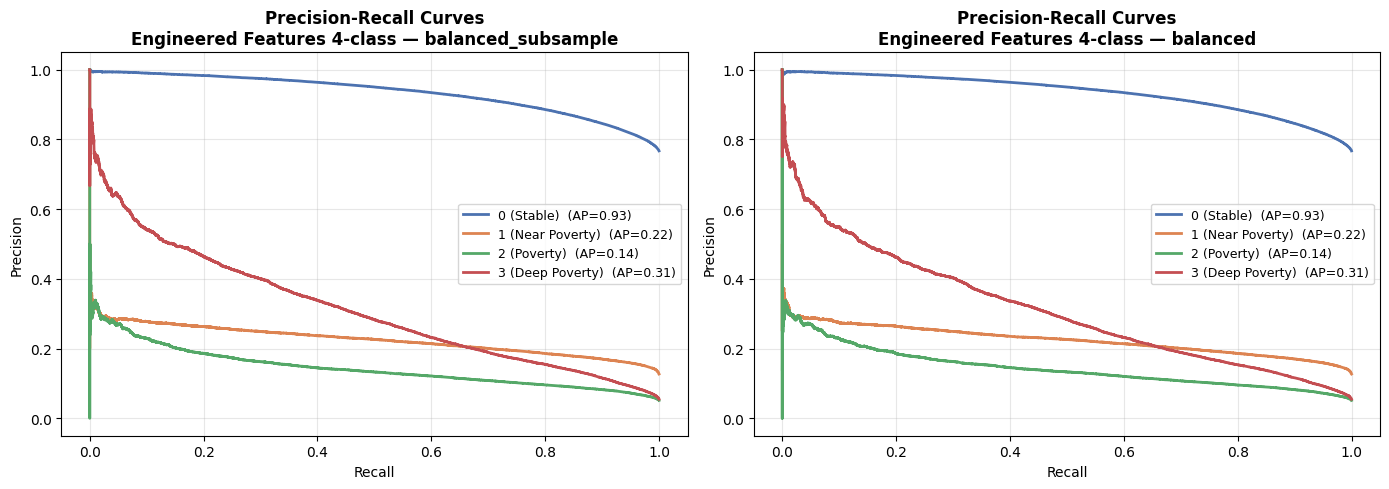

In [9]:
# Precision-Recall Curves — Engineered Features (4-class)
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

classes     = [0, 1, 2, 3]
class_names = ["0 (Stable)", "1 (Near Poverty)", "2 (Poverty)", "3 (Deep Poverty)"]
colours     = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

y_test_4c_bin = label_binarize(y_test_4c, classes=classes)
proba_4c_bss  = rf_4c_bss.predict_proba(X_test_4c)
proba_4c_bal  = rf_4c_bal.predict_proba(X_test_4c)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, proba, title in zip(axes,
                             [proba_4c_bss, proba_4c_bal],
                             ["balanced_subsample", "balanced"]):
    for i, (cls, col) in enumerate(zip(class_names, colours)):
        prec, rec, _ = precision_recall_curve(y_test_4c_bin[:, i], proba[:, i])
        ap = average_precision_score(y_test_4c_bin[:, i], proba[:, i])
        ax.plot(rec, prec, color=col, lw=2, label=f"{cls}  (AP={ap:.2f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"Precision-Recall Curves\nEngineered Features 4-class — {title}", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


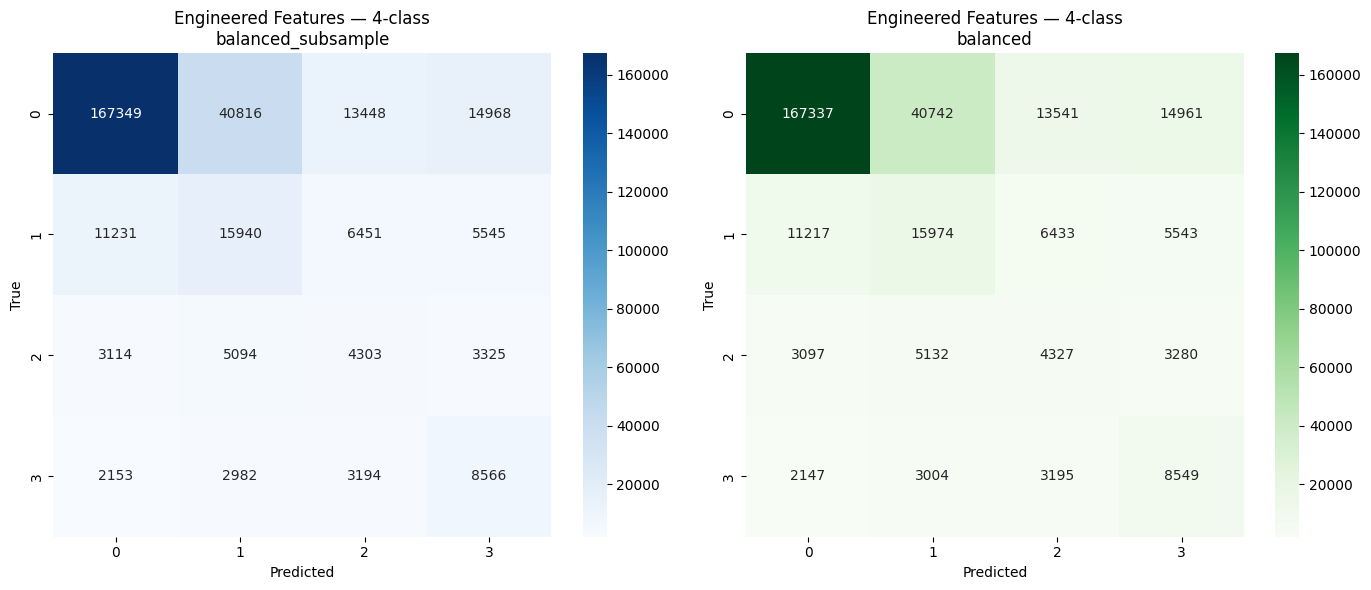

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_4c_bss = confusion_matrix(y_test_4c, y_pred_4c_bss)
cm_4c_bal = confusion_matrix(y_test_4c, y_pred_4c_bal)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_4c_bss, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Engineered Features — 4-class\nbalanced_subsample")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_4c_bal, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Engineered Features — 4-class\nbalanced")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import classification_report

report_4c_bss = classification_report(y_test_4c, y_pred_4c_bss, output_dict=True)
report_4c_bal = classification_report(y_test_4c, y_pred_4c_bal, output_dict=True)

rows = []
for c in ["0", "1", "2", "3"]:
    rows.append({
        "class": c,
        "precision_subsample": report_4c_bss[c]["precision"],
        "precision_balanced":  report_4c_bal[c]["precision"],
        "recall_subsample":    report_4c_bss[c]["recall"],
        "recall_balanced":     report_4c_bal[c]["recall"],
        "f1_subsample":        report_4c_bss[c]["f1-score"],
        "f1_balanced":         report_4c_bal[c]["f1-score"],
    })

df_compare_4c = pd.DataFrame(rows)
display(df_compare_4c)

print(f"\nMacro F1    (balanced_subsample): {report_4c_bss['macro avg']['f1-score']:.4f}")
print(f"Macro F1    (balanced):           {report_4c_bal['macro avg']['f1-score']:.4f}")
print(f"Weighted F1 (balanced_subsample): {report_4c_bss['weighted avg']['f1-score']:.4f}")
print(f"Weighted F1 (balanced):           {report_4c_bal['weighted avg']['f1-score']:.4f}")

,class,precision_subsample,precision_balanced,recall_subsample,recall_balanced,f1_subsample,f1_balanced
0,0,0.910262,0.910440,0.707364,0.707314,0.796089,0.796124
1,1,0.245866,0.246315,0.406975,0.407843,0.306541,0.307136
2,2,0.157067,0.157368,0.271723,0.273238,0.199066,0.199714
3,3,0.264350,0.264405,0.507014,0.506008,0.347512,0.347323



Macro F1    (balanced_subsample): 0.4123
Macro F1    (balanced):           0.4126
Weighted F1 (balanced_subsample): 0.6787
Weighted F1 (balanced):           0.6788


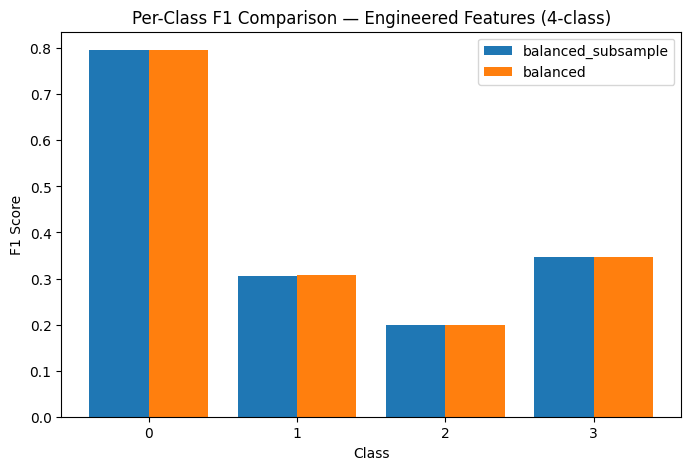

In [12]:
import matplotlib.pyplot as plt

x = range(len(df_compare_4c))

plt.figure(figsize=(8, 5))
plt.bar([i - 0.2 for i in x], df_compare_4c["f1_subsample"], width=0.4, label="balanced_subsample")
plt.bar([i + 0.2 for i in x], df_compare_4c["f1_balanced"],  width=0.4, label="balanced")

plt.xticks(x, df_compare_4c["class"])
plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Comparison — Engineered Features (4-class)")
plt.legend()
plt.show()

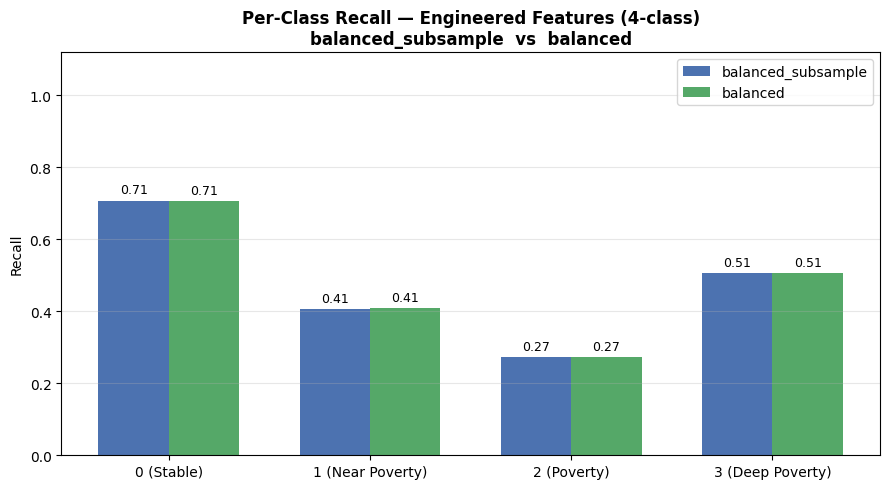

In [13]:
# Per-Class Recall Comparison,Engineered Features (4-class)
import matplotlib.pyplot as plt
import numpy as np

classes    = ["0 (Stable)", "1 (Near Poverty)", "2 (Poverty)", "3 (Deep Poverty)"]
x          = np.arange(len(classes))
width      = 0.35

recall_4c_bss_vals = [report_4c_bss[c]["recall"] for c in ["0","1","2","3"]]
recall_4c_bal_vals = [report_4c_bal[c]["recall"] for c in ["0","1","2","3"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, recall_4c_bss_vals, width, label="balanced_subsample", color="#4C72B0")
bars2 = ax.bar(x + width/2, recall_4c_bal_vals,  width, label="balanced",           color="#55A868")

ax.bar_label(bars1, fmt="%.2f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.2f", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=10)
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.12)
ax.set_title("Per-Class Recall — Engineered Features (4-class)\n"
             "balanced_subsample  vs  balanced", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


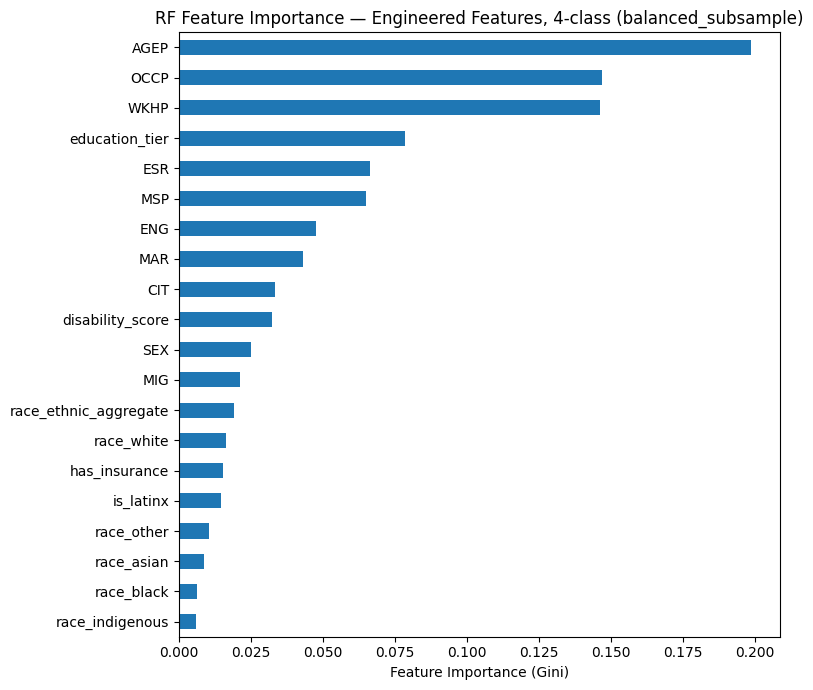

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

importance_4c = pd.Series(
    rf_4c_bss.feature_importances_,
    index=optimal_features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(optimal_features) * 0.35)))
importance_4c.plot(kind="barh", ax=ax)
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("RF Feature Importance — Engineered Features, 4-class (balanced_subsample)")
plt.tight_layout()
plt.show()

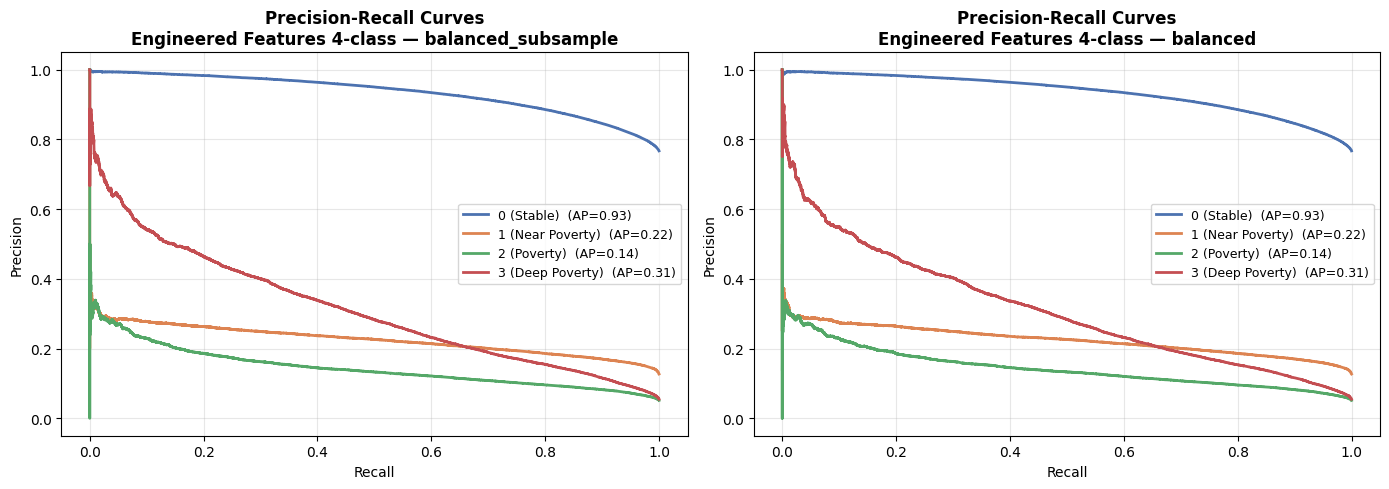

In [15]:
# Precision-Recall Curves,Engineered Features (4-class)
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

classes     = [0, 1, 2, 3]
class_names = ["0 (Stable)", "1 (Near Poverty)", "2 (Poverty)", "3 (Deep Poverty)"]
colours     = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

y_test_4c_bin = label_binarize(y_test_4c, classes=classes)
proba_4c_bss  = rf_4c_bss.predict_proba(X_test_4c)
proba_4c_bal  = rf_4c_bal.predict_proba(X_test_4c)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, proba, title in zip(axes,
                             [proba_4c_bss, proba_4c_bal],
                             ["balanced_subsample", "balanced"]):
    for i, (cls, col) in enumerate(zip(class_names, colours)):
        prec, rec, _ = precision_recall_curve(y_test_4c_bin[:, i], proba[:, i])
        ap = average_precision_score(y_test_4c_bin[:, i], proba[:, i])
        ax.plot(rec, prec, color=col, lw=2, label=f"{cls}  (AP={ap:.2f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"Precision-Recall Curves\nEngineered Features 4-class — {title}", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 2) Random Forest on Engineered Feature Set — Binary (`binary_target`)

Using the same engineered CSVs and optimal feature list from `3c_Preprocessing_XGBoost.ipynb`,
targeting the binary `binary_target` label (0 = Stable, 1 = At-Risk).


In [16]:
import json
import pandas as pd
from pathlib import Path

data_dir = Path("../3_Data_Preprocessing/preprocessing_data")

# Load engineered train/test sets
df_train_eng = pd.read_csv(data_dir / "train_engineered.csv")
df_test_eng  = pd.read_csv(data_dir / "test_engineered.csv")

# Load feature metadata produced by the XGBoost preprocessing notebook
with open(data_dir / "feature_engineering_metadata.json") as f:
    metadata = json.load(f)

optimal_features = metadata["optimal_features"]

# Targets
X_train_eng = df_train_eng[optimal_features]
y_train_eng = df_train_eng["binary_target"]

X_test_eng = df_test_eng[optimal_features]
y_test_eng = df_test_eng["binary_target"]

print(f"Optimal features ({len(optimal_features)}): {optimal_features}")
print(f"X_train_eng: {X_train_eng.shape}, y_train_eng: {y_train_eng.shape}")
print(f"X_test_eng:  {X_test_eng.shape},  y_test_eng:  {y_test_eng.shape}")
print(f"\ny_train_eng distribution: {y_train_eng.value_counts().to_dict()}")
print(f"y_test_eng  distribution: {y_test_eng.value_counts().to_dict()}")

Optimal features (20): ['MSP', 'education_tier', 'WKHP', 'ESR', 'ENG', 'CIT', 'MIG', 'has_insurance', 'MAR', 'is_latinx', 'AGEP', 'SEX', 'race_black', 'OCCP', 'race_white', 'race_asian', 'race_indigenous', 'race_other', 'race_ethnic_aggregate', 'disability_score']
X_train_eng: (1490293, 20), y_train_eng: (1490293,)
X_test_eng:  (308479, 20),  y_test_eng:  (308479,)

y_train_eng distribution: {0: 1128200, 1: 362093}
y_test_eng  distribution: {0: 236581, 1: 71898}


### Random Forest with balanced_subsample on engineered features

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_eng_bss = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_eng_bss.fit(X_train_eng, y_train_eng)
y_pred_eng_bss = rf_eng_bss.predict(X_test_eng)

print("=== RF (Engineered Features, balanced_subsample) ===")
print(classification_report(y_test_eng, y_pred_eng_bss))
print("Confusion matrix:")
print(confusion_matrix(y_test_eng, y_pred_eng_bss))

=== RF (Engineered Features, balanced_subsample) ===
              precision    recall  f1-score   support

           0       0.90      0.76      0.82    236581
           1       0.47      0.72      0.57     71898

    accuracy                           0.75    308479
   macro avg       0.69      0.74      0.70    308479
weighted avg       0.80      0.75      0.76    308479

Confusion matrix:
[[179302  57279]
 [ 20171  51727]]


### Random Forest with balanced on engineered features

In [18]:
rf_eng_bal = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_eng_bal.fit(X_train_eng, y_train_eng)
y_pred_eng_bal = rf_eng_bal.predict(X_test_eng)

print("=== RF (Engineered Features, balanced) ===")
print(classification_report(y_test_eng, y_pred_eng_bal))
print("Confusion matrix:")
print(confusion_matrix(y_test_eng, y_pred_eng_bal))

=== RF (Engineered Features, balanced) ===
              precision    recall  f1-score   support

           0       0.90      0.76      0.82    236581
           1       0.47      0.72      0.57     71898

    accuracy                           0.75    308479
   macro avg       0.69      0.74      0.70    308479
weighted avg       0.80      0.75      0.76    308479

Confusion matrix:
[[179279  57302]
 [ 20146  51752]]


In [19]:
#Tuning Cell, Do not run again
'''rf_base_bin = RandomForestClassifier(
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

param_dist_bin = {
    "n_estimators":      randint(100, 301),
    "max_depth":         [None, 10, 20, 30],
    "min_samples_split": randint(5, 20),
    "min_samples_leaf":  randint(2, 10),
    "max_features":      ["sqrt", "log2", 0.5],
}

search_bin = RandomizedSearchCV(
    estimator=rf_base_bin,
    param_distributions=param_dist_bin,
    n_iter=20,
    scoring="f1_macro",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=1,
    verbose=2,
    random_state=42,
    refit=True
)

search_bin.fit(X_train_eng, y_train_eng)

print("Best params (binary):", search_bin.best_params_)
print(f"Best CV macro F1:     {search_bin.best_score_:.4f}")

y_pred_bin_tuned = search_bin.best_estimator_.predict(X_test_eng)
print("\n=== Tuned RF (Binary) ===")
print(classification_report(y_test_eng, y_pred_bin_tuned))
'''

#Output of this cell
'''Best params (binary): {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 6, 'min_samples_split': 7, 'n_estimators': 234}
Best CV macro F1:     0.7048'''

"Best params (binary): {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 6, 'min_samples_split': 7, 'n_estimators': 234}\nBest CV macro F1:     0.7048"

### Visualisations — Engineered Feature Models

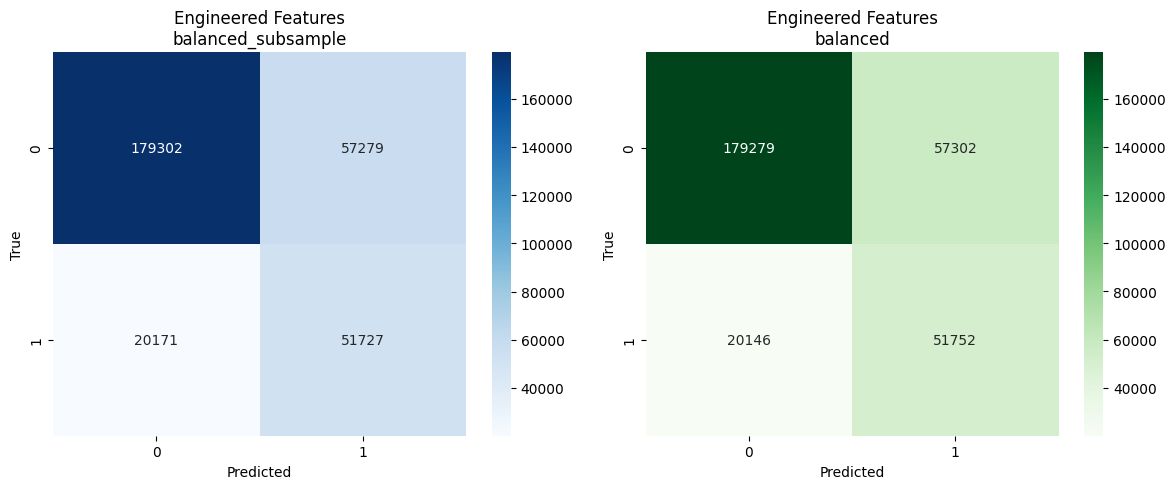

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_eng_bss = confusion_matrix(y_test_eng, y_pred_eng_bss)
cm_eng_bal = confusion_matrix(y_test_eng, y_pred_eng_bal)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_eng_bss, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Engineered Features\nbalanced_subsample")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_eng_bal, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Engineered Features\nbalanced")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import classification_report, f1_score

report_eng_bss = classification_report(y_test_eng, y_pred_eng_bss, output_dict=True)
report_eng_bal = classification_report(y_test_eng, y_pred_eng_bal, output_dict=True)

rows = []
for c in ["0", "1"]:
    rows.append({
        "class": c,
        "precision_subsample": report_eng_bss[c]["precision"],
        "precision_balanced":  report_eng_bal[c]["precision"],
        "recall_subsample":    report_eng_bss[c]["recall"],
        "recall_balanced":     report_eng_bal[c]["recall"],
        "f1_subsample":        report_eng_bss[c]["f1-score"],
        "f1_balanced":         report_eng_bal[c]["f1-score"],
    })

df_compare_eng = pd.DataFrame(rows)
print(df_compare_eng.to_string(index=False))

print(f"\nMacro F1 (balanced_subsample): {report_eng_bss['macro avg']['f1-score']:.4f}")
print(f"Macro F1 (balanced):           {report_eng_bal['macro avg']['f1-score']:.4f}")
print(f"Weighted F1 (balanced_subsample): {report_eng_bss['weighted avg']['f1-score']:.4f}")
print(f"Weighted F1 (balanced):           {report_eng_bal['weighted avg']['f1-score']:.4f}")

class  precision_subsample  precision_balanced  recall_subsample  recall_balanced  f1_subsample  f1_balanced
    0             0.898879            0.898980          0.757888         0.757791      0.822384     0.822369
    1             0.474534            0.474554          0.719450         0.719797      0.571872     0.571997

Macro F1 (balanced_subsample): 0.6971
Macro F1 (balanced):           0.6972
Weighted F1 (balanced_subsample): 0.7640
Weighted F1 (balanced):           0.7640


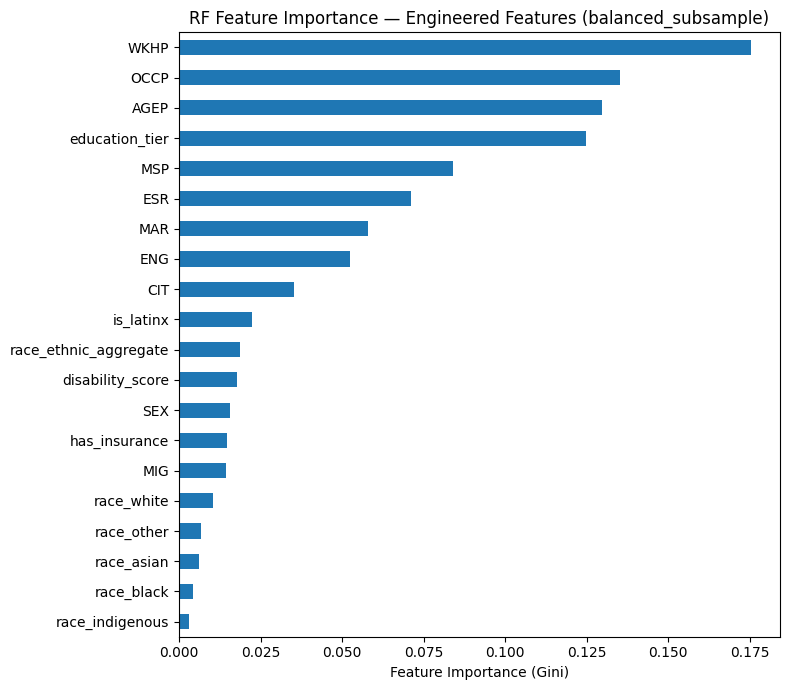

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance from the balanced_subsample binary
importance_eng = pd.Series(
    rf_eng_bss.feature_importances_,
    index=optimal_features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(optimal_features) * 0.35)))
importance_eng.plot(kind="barh", ax=ax)
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("RF Feature Importance — Engineered Features (balanced_subsample)")
plt.tight_layout()
plt.show()

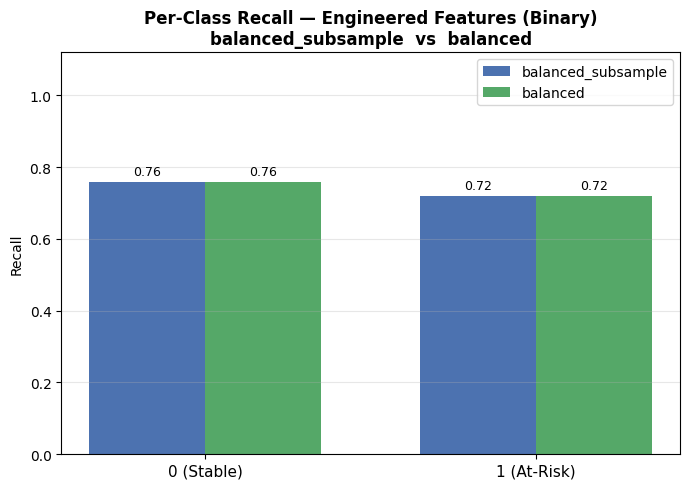

In [23]:
# Per-Class Recall Comparison,engineered featuresBinary
import matplotlib.pyplot as plt
import numpy as np

classes   = ["0 (Stable)", "1 (At-Risk)"]
x         = np.arange(len(classes))
width     = 0.35

recall_eng_bss_vals = [report_eng_bss[c]["recall"] for c in ["0","1"]]
recall_eng_bal_vals = [report_eng_bal[c]["recall"] for c in ["0","1"]]

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, recall_eng_bss_vals, width, label="balanced_subsample", color="#4C72B0")
bars2 = ax.bar(x + width/2, recall_eng_bal_vals,  width, label="balanced",           color="#55A868")

ax.bar_label(bars1, fmt="%.2f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.2f", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.12)
ax.set_title("Per-Class Recall — Engineered Features (Binary)\n"
             "balanced_subsample  vs  balanced", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


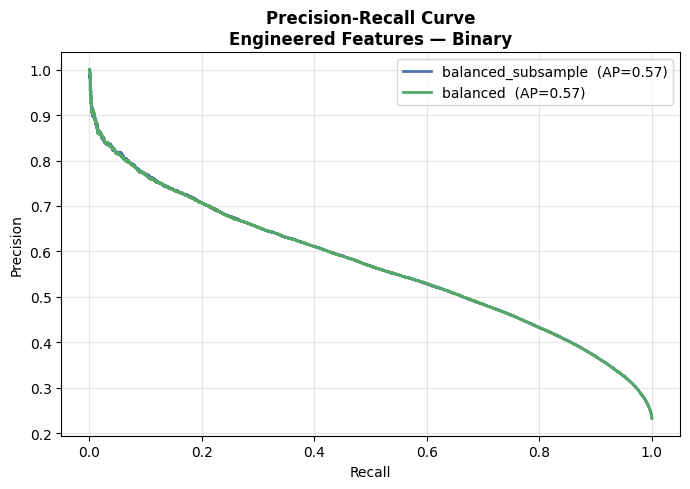

In [24]:
# Precision-Recall Curve, Engineered Features,Binary
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

proba_eng_bss = rf_eng_bss.predict_proba(X_test_eng)[:, 1]
proba_eng_bal = rf_eng_bal.predict_proba(X_test_eng)[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))

for proba, label, colour in zip(
        [proba_eng_bss, proba_eng_bal],
        ["balanced_subsample", "balanced"],
        ["#4C72B0", "#55A868"]):
    prec, rec, _ = precision_recall_curve(y_test_eng, proba)
    ap = average_precision_score(y_test_eng, proba)
    ax.plot(rec, prec, color=colour, lw=2, label=f"{label}  (AP={ap:.2f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve\nEngineered Features — Binary", fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3) Summary — All Models Compared



In [25]:
# Gather summary metrics for all 6 models
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np

# macro recall from a classification_report dict
def macro_recall(rep):
    return rep["macro avg"]["recall"]

# Helper — OvR AUC 
def ovr_auc(model, X, y):
    proba = model.predict_proba(X)
    try:
        return roc_auc_score(y, proba, multi_class="ovr", average="macro")
    except Exception:
        return float("nan")


model_labels = [
    "Eng4c\nBSS",
    "Eng4c\nBAL",
    "BinEng\nBSS",
    "BinEng\nBAL",
]

macro_f1_vals = [
    report_4c_bss["macro avg"]["f1-score"],
    report_4c_bal["macro avg"]["f1-score"],
    report_eng_bss["macro avg"]["f1-score"],
    report_eng_bal["macro avg"]["f1-score"],
]

macro_recall_vals = [
    macro_recall(report_4c_bss),
    macro_recall(report_4c_bal),
    macro_recall(report_eng_bss),
    macro_recall(report_eng_bal),
]

auc_vals = [
    ovr_auc(rf_4c_bss,  X_test_4c,     y_test_4c),
    ovr_auc(rf_4c_bal,  X_test_4c,     y_test_4c),
    ovr_auc(rf_eng_bss, X_test_eng,    y_test_eng),
    ovr_auc(rf_eng_bal, X_test_eng,    y_test_eng),
]

accuracy_vals = [
    accuracy_score(y_test_4c,  y_pred_4c_bss),
    accuracy_score(y_test_4c,  y_pred_4c_bal),
    accuracy_score(y_test_eng, y_pred_eng_bss),
    accuracy_score(y_test_eng, y_pred_eng_bal),
]

print("Model Summary")
print(f"{'Model':<14} {'Macro F1':>9} {'Macro Recall':>13} {'OvR AUC':>9} {'Accuracy':>10}")
print("-" * 58)
for lbl, f1, rec, auc, acc in zip(model_labels, macro_f1_vals, macro_recall_vals, auc_vals, accuracy_vals):
    short = lbl.replace("\n", " ")
    print(f"{short:<14} {f1:>9.4f} {rec:>13.4f} {auc:>9.4f} {acc:>10.4f}")


Model Summary
Model           Macro F1  Macro Recall   OvR AUC   Accuracy
----------------------------------------------------------
Eng4c BSS         0.4123        0.4733    0.7839     0.6359
Eng4c BAL         0.4126        0.4736    0.7838     0.6360
BinEng BSS        0.6971        0.7387       nan     0.7489
BinEng BAL        0.6972        0.7388       nan     0.7489


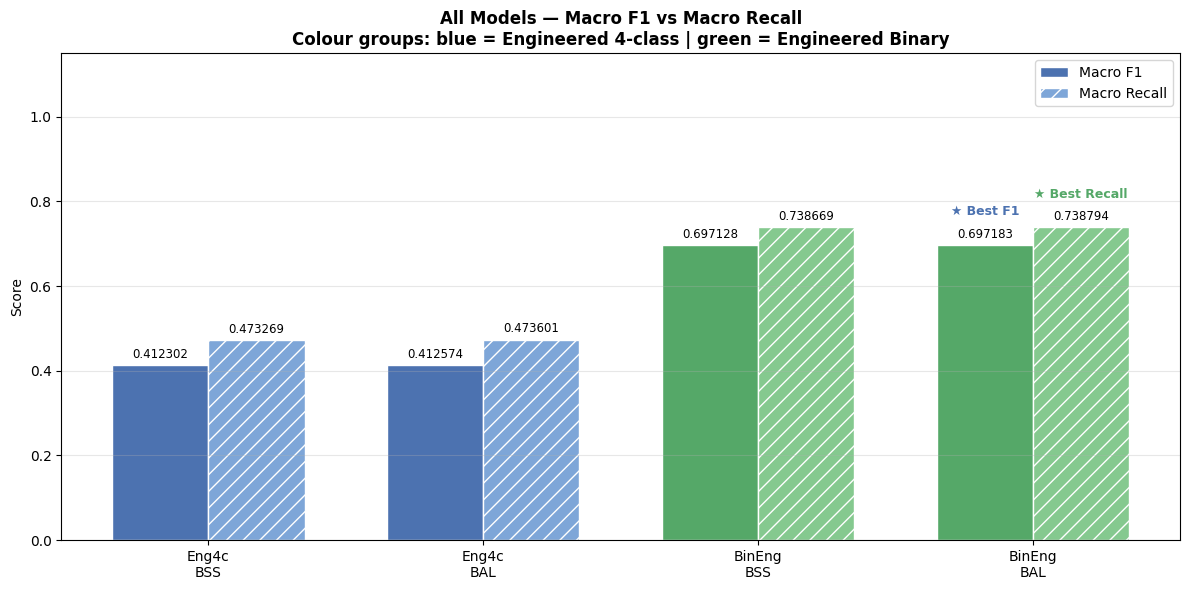

In [26]:
# Bar chart: Macro F1 vs Macro Recall for all models
import matplotlib.pyplot as plt
import numpy as np

x     = np.arange(len(model_labels))
width = 0.35

# colour-code by task group: blue = Engineered 4-class | green = Engineered Binary
colours_f1  = ["#4C72B0", "#4C72B0", "#55A868", "#55A868"]
colours_rec = ["#7EA6D8", "#7EA6D8", "#85C98F", "#85C98F"]

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, macro_f1_vals,     width, color=colours_f1,  label="Macro F1",     edgecolor="white")
bars2 = ax.bar(x + width/2, macro_recall_vals, width, color=colours_rec, label="Macro Recall", edgecolor="white", hatch="//")

ax.bar_label(bars1, fmt="%.6f", padding=3, fontsize=8.5)
ax.bar_label(bars2, fmt="%.6f", padding=3, fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.15)
ax.set_title("All Models — Macro F1 vs Macro Recall\n"
             "Colour groups: blue = Engineered 4-class | green = Engineered Binary",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

# Annotate best model per metric
best_f1  = int(np.argmax(macro_f1_vals))
best_rec = int(np.argmax(macro_recall_vals))
ax.annotate("★ Best F1",  xy=(best_f1  - width/2, macro_f1_vals[best_f1]  + 0.07),
            ha="center", color="#4C72B0", fontsize=9, fontweight="bold")
ax.annotate("★ Best Recall", xy=(best_rec + width/2, macro_recall_vals[best_rec] + 0.07),
            ha="center", color="#55A868", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


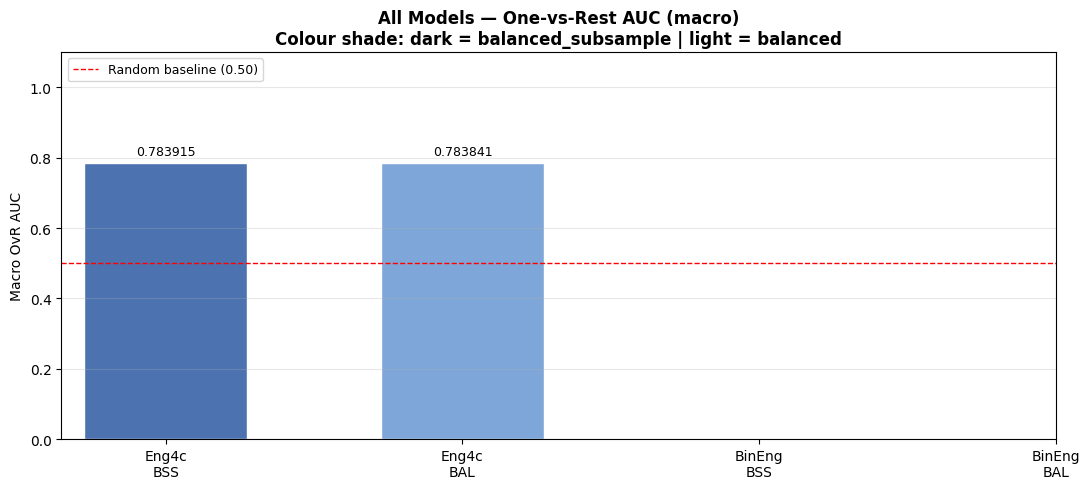

In [27]:
# Bar chart: One-vs-Rest AUC for all models
import matplotlib.pyplot as plt
import numpy as np

# blue pair = Engineered 4-class, green pair = Engineered Binary
colours_auc = ["#4C72B0", "#7EA6D8", "#55A868", "#85C98F"]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(np.arange(len(model_labels)), auc_vals, color=colours_auc, edgecolor="white", width=0.55)
ax.bar_label(bars, fmt="%.6f", padding=4, fontsize=9)

ax.set_xticks(np.arange(len(model_labels)))
ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylabel("Macro OvR AUC")
ax.set_ylim(0, 1.1)
ax.set_title("All Models — One-vs-Rest AUC (macro)\n"
             "Colour shade: dark = balanced_subsample | light = balanced",
             fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Random baseline (0.50)")
ax.legend(fontsize=9)

best_auc = int(np.argmax(auc_vals))
ax.annotate("★ Best AUC", xy=(best_auc, auc_vals[best_auc] + 0.02),
            ha="center", color="darkred", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


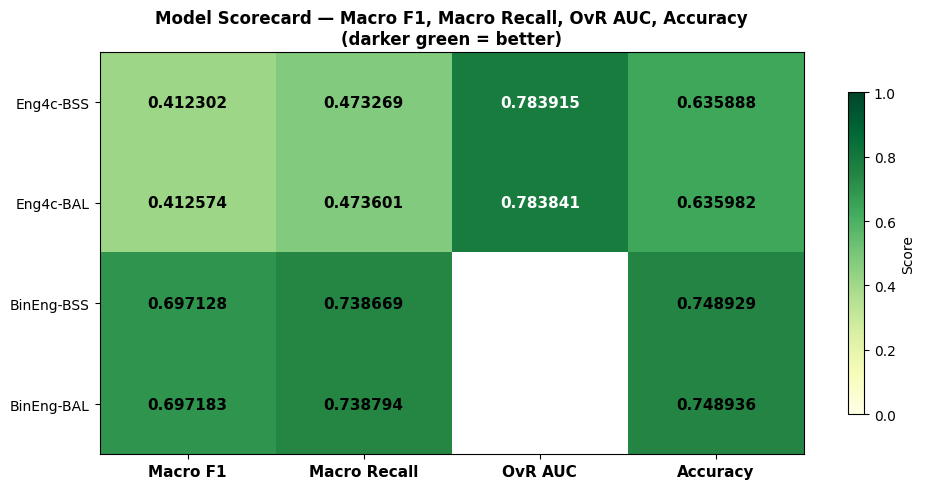

In [28]:
#  Heatmap scorecard: all 6 models × 4 key metrics
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

short_labels = ["Eng4c-BSS","Eng4c-BAL","BinEng-BSS","BinEng-BAL"]
metrics      = ["Macro F1", "Macro Recall", "OvR AUC", "Accuracy"]

data = np.array([macro_f1_vals, macro_recall_vals, auc_vals, accuracy_vals]).T  # shape (6, 4)
df_heat = pd.DataFrame(data, index=short_labels, columns=metrics)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(df_heat.values, cmap="YlGn", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics, fontsize=11, fontweight="bold")
ax.set_yticks(range(len(short_labels)))
ax.set_yticklabels(short_labels, fontsize=10)

# Annotate each cell
for i in range(len(short_labels)):
    for j in range(len(metrics)):
        val = df_heat.iloc[i, j]
        ax.text(j, i, f"{val:.6f}", ha="center", va="center",
                fontsize=11, fontweight="bold",
                color="black" if val < 0.75 else "white")

plt.colorbar(im, ax=ax, shrink=0.8, label="Score")
ax.set_title("Model Scorecard — Macro F1, Macro Recall, OvR AUC, Accuracy\n"
             "(darker green = better)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()